# Week 6 · Notebook 4 — Multi-Objective Metaheuristics

**Goals**
- Define Pareto dominance, the Pareto set and front, the ideal and nadir points.
- Implement fast non-dominated sorting (Deb, Pratap, Agarwal & Meyarivan 2002) and validate it against brute-force
  dominance peeling; implement crowding distance and validate it on a front with known spacing.
- Implement the ZDT1/ZDT2/ZDT3 test problems (Zitzler, Deb & Thiele 2000) with their analytic Pareto fronts.
- Implement the exact 2-D hypervolume and validate it against closed-form values and Monte Carlo; implement IGD.
- Implement NSGA-II and MOEA/D with Tchebycheff decomposition (Zhang & Li 2007) and compare them at equal budgets.

**Prerequisites:** Week 4 (GA, SBX, polynomial mutation), Notebook 1 (ask–tell view).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from utils import PALETTE
from scipy import stats

## 1. Pareto dominance

For $F:\mathcal{X}\to\mathbb{R}^M$ (all objectives minimised), $a$ **dominates** $b$, written $a\prec b$, iff
$F_m(a)\le F_m(b)$ for all $m$ and $F_m(a)\lt F_m(b)$ for at least one $m$. The **Pareto set** is
$\mathcal{P}=\lbrace x\in\mathcal{X}:\nexists\,x'\prec x\rbrace$, its image $F(\mathcal{P})$ the **Pareto front**. The
**ideal point** is $z^{\ast}_m=\min_{x}F_m(x)$, the **nadir point** $z^{\text{nad}}_m=\max_{x\in\mathcal{P}}F_m(x)$
(the worst value *on the front*, not over $\mathcal{X}$). Dominance is a strict partial order; the goal of a
multi-objective metaheuristic is a finite set that is (i) close to the front (convergence), (ii) well spread along it
(diversity).

**Non-dominated sorting** partitions a population into fronts $\mathcal{F}_1$ (non-dominated), $\mathcal{F}_2$
(non-dominated once $\mathcal{F}_1$ is removed), … The naive peeling approach costs $O(MN^2)$ *per front*, i.e.
$O(MN^3)$ worst case. Deb et al. (2002) compute, once, for each $p$ the set $S_p$ of points it dominates and the
counter $n_p$ of points dominating it ($O(MN^2)$), then peel fronts by decrementing counters:

```text
FAST-NON-DOMINATED-SORT(P):
    for p in P: S_p <- {q : p dominates q};  n_p <- |{q : q dominates p}|
    F_1 <- {p : n_p = 0};  i <- 1
    while F_i not empty:
        Q <- {}
        for p in F_i: for q in S_p: n_q <- n_q - 1; if n_q = 0: Q <- Q + {q}
        i <- i + 1; F_i <- Q
```

In [2]:
def dominance_matrix(F):
    """D[i, j] = True iff F[i] dominates F[j] (minimisation). O(M N^2), vectorised."""
    le = np.all(F[:, None, :] <= F[None, :, :], axis=2)
    lt = np.any(F[:, None, :] < F[None, :, :], axis=2)
    return le & lt

def fast_non_dominated_sort(F):
    """Deb et al. (2002): counters n_p and dominated sets S_p (rows of D). Returns front index per point (0 = best)."""
    D = dominance_matrix(F)
    n = D.sum(0).astype(int)            # n_p: how many dominate p
    rank = np.full(len(F), -1)
    current = np.flatnonzero(n == 0); i = 0
    while len(current):
        rank[current] = i
        n = n - D[current].sum(0)       # for p in F_i, for q in S_p: n_q -= 1
        n[rank >= 0] = -1               # already assigned
        current = np.flatnonzero(n == 0); i += 1
    return rank

def naive_fronts(F):
    """Brute-force peeling with explicit pairwise dominance checks (reference implementation)."""
    remaining, rank, i = list(range(len(F))), np.full(len(F), -1), 0
    while remaining:
        front = [p for p in remaining
                 if not any(np.all(F[q] <= F[p]) and np.any(F[q] < F[p]) for q in remaining if q != p)]
        rank[front] = i; remaining = [p for p in remaining if p not in front]; i += 1
    return rank

for M, N, seed in [(2, 200, 0), (3, 150, 1), (4, 100, 2)]:
    Fr = np.round(np.random.default_rng(seed).random((N, M)), 1)  # rounding creates ties and duplicates
    check_true(np.array_equal(fast_non_dominated_sort(Fr), naive_fronts(Fr)),
               f"fast non-dominated sort == brute-force peeling (M={M}, N={N}, with ties; {fast_non_dominated_sort(Fr).max() + 1} fronts)")

[PASS] fast non-dominated sort == brute-force peeling (M=2, N=200, with ties; 20 fronts)
[PASS] fast non-dominated sort == brute-force peeling (M=3, N=150, with ties; 16 fronts)
[PASS] fast non-dominated sort == brute-force peeling (M=4, N=100, with ties; 6 fronts)


**Crowding distance** (Deb et al. 2002) estimates the density around a point within its front: for each objective sort
the front, give the two extremes $\infty$ and every interior point $(f_m^{(i+1)}-f_m^{(i-1)})/(f_m^{\max}-f_m^{\min})$,
summed over $m$. For $n$ equally spaced points on the line $f_2=1-f_1$ every interior point therefore has distance
exactly $2\cdot\frac{2}{n-1}$.

In [3]:
def crowding_distance(F):
    n, M = F.shape
    cd = np.zeros(n)
    if n <= 2:
        return np.full(n, np.inf)
    for m in range(M):
        o = np.argsort(F[:, m], kind="stable"); span = F[o[-1], m] - F[o[0], m]
        cd[o[0]] = cd[o[-1]] = np.inf
        if span > 0:
            cd[o[1:-1]] += (F[o[2:], m] - F[o[:-2], m]) / span
    return cd

n_line = 11
line = np.c_[np.linspace(0, 1, n_line), 1 - np.linspace(0, 1, n_line)]
cd_line = crowding_distance(rng.permutation(line))
check_true(np.sum(np.isinf(cd_line)) == 2, "crowding: exactly the two extremes get infinity")
check_close(np.sort(cd_line)[:-2], np.full(n_line - 2, 4 / (n_line - 1)), "crowding of equally spaced points = 2 * 2/(n-1)")

[PASS] crowding: exactly the two extremes get infinity
[PASS] crowding of equally spaced points = 2 * 2/(n-1): got [0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4], expected [0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]


## 2. ZDT test problems and their analytic fronts

ZDT problems (Zitzler, Deb & Thiele 2000) have $n=30$ variables in $[0,1]$, $f_1=x_1$,
$g(x)=1+\frac{9}{n-1}\sum_{i=2}^{n}x_i$ and $f_2=g\,h(f_1,g)$ with

| problem | $h(f_1,g)$ | Pareto front ($g=1$) | shape |
|---|---|---|---|
| ZDT1 | $1-\sqrt{f_1/g}$ | $f_2 = 1-\sqrt{f_1}$ | convex |
| ZDT2 | $1-(f_1/g)^2$ | $f_2 = 1-f_1^2$ | concave |
| ZDT3 | $1-\sqrt{f_1/g}-(f_1/g)\sin(10\pi f_1)$ | non-dominated part of $f_2=1-\sqrt{f_1}-f_1\sin(10\pi f_1)$ | 5 disconnected pieces |

The Pareto set is $\lbrace x: x_2=\dots=x_n=0\rbrace$ (then $g=1$, its minimum). With reference point $r=(1.1,1.1)$
the hypervolume of the true fronts has closed forms:
$\mathrm{HV}_{\text{ZDT1}}=\int_0^1(1.1-1+\sqrt{x})\,dx+0.1\cdot1.1 = 0.21+\tfrac23$ and
$\mathrm{HV}_{\text{ZDT2}}=\int_0^1(0.1+x^2)\,dx+0.11=0.21+\tfrac13$.

In [4]:
def zdt(name):
    def F(X):
        X = np.atleast_2d(X); f1 = X[:, 0]
        g = 1 + 9 * X[:, 1:].sum(1) / (X.shape[1] - 1); u = f1 / g
        if name == "ZDT1": h = 1 - np.sqrt(u)
        elif name == "ZDT2": h = 1 - u**2
        else: h = 1 - np.sqrt(u) - u * np.sin(10 * np.pi * f1)
        return np.c_[f1, g * h]
    return F

def true_front(name, n=2000):
    f1 = np.linspace(0, 1, n if name != "ZDT3" else 40 * n)
    P = zdt(name)(np.c_[f1, np.zeros((len(f1), 29))])
    if name == "ZDT3":
        o = np.argsort(P[:, 0], kind="stable")   # 2-D sweep: keep points whose f2 beats every smaller f1
        P = P[o][P[o, 1] < np.minimum.accumulate(np.r_[np.inf, P[o, 1]])[:-1]]
        P = P[np.linspace(0, len(P) - 1, n).astype(int)]
    return P

def hv2d(F, ref):
    """Exact hypervolume of a 2-D point set w.r.t. ref (minimisation): sweep over f1."""
    F = F[np.all(F < ref, axis=1)]
    if len(F) == 0:
        return 0.0
    F = F[np.lexsort((F[:, 1], F[:, 0]))]
    hv, best_f2 = 0.0, ref[1]
    for i in range(len(F)):
        if F[i, 1] < best_f2:
            # slab between this point's f2 and the best f2 so far, extended to ref[0]
            hv += (ref[0] - F[i, 0]) * (best_f2 - F[i, 1])
            best_f2 = F[i, 1]
    return hv

def hv_monte_carlo(F, ref, n=400000, seed=0):
    r = np.random.default_rng(seed)
    lo = F.min(0); U = lo + r.random((n, 2)) * (ref - lo)
    dom = np.zeros(n, bool)
    for p in F:
        dom |= np.all(U >= p, axis=1)
    frac = dom.mean()
    return frac * np.prod(ref - lo), np.sqrt(frac * (1 - frac) / n) * np.prod(ref - lo)

def igd(A, Ref):
    """Inverted generational distance: mean distance from reference-front points to the approximation set A."""
    return np.mean(np.min(np.sqrt(((Ref[:, None, :] - A[None, :, :]) ** 2).sum(-1)), axis=1))

ref = np.array([1.1, 1.1])
fronts = {p: true_front(p) for p in ["ZDT1", "ZDT2", "ZDT3"]}
hv_true = {p: hv2d(fronts[p], ref) for p in fronts}
check_close(hv_true["ZDT1"], 0.21 + 2 / 3, "HV of the ZDT1 front (2000 pts) vs closed form 0.21 + 2/3", atol=1e-3)
check_close(hv_true["ZDT2"], 0.21 + 1 / 3, "HV of the ZDT2 front (2000 pts) vs closed form 0.21 + 1/3", atol=1e-3)
for p in fronts:
    sub = fronts[p][rng.choice(len(fronts[p]), 30, replace=False)]
    mc, se = hv_monte_carlo(sub, ref)
    check_close(hv2d(sub, ref), mc, f"{p}: exact 2-D HV of 30 random front points vs Monte Carlo (4 SE)", atol=4 * se)
print("true-front HV:", {p: round(float(v), 4) for p, v in hv_true.items()})

[PASS] HV of the ZDT1 front (2000 pts) vs closed form 0.21 + 2/3: got 0.876414, expected 0.876667
[PASS] HV of the ZDT2 front (2000 pts) vs closed form 0.21 + 1/3: got 0.543083, expected 0.543333


[PASS] ZDT1: exact 2-D HV of 30 random front points vs Monte Carlo (4 SE): got 0.847605, expected 0.84778


[PASS] ZDT2: exact 2-D HV of 30 random front points vs Monte Carlo (4 SE): got 0.500349, expected 0.500463


[PASS] ZDT3: exact 2-D HV of 30 random front points vs Monte Carlo (4 SE): got 1.300804, expected 1.302161
true-front HV: {'ZDT1': 0.8764, 'ZDT2': 0.5431, 'ZDT3': 1.3316}


The sweep in `hv2d` is correct only if it skips dominated points: after sorting by $f_1$, a point contributes the
rectangle between its $f_2$ and the best $f_2$ seen so far, extended to $r_1$ — the union of such slabs is the
dominated region. The Monte-Carlo check is independent of this reasoning.

## 3. NSGA-II

NSGA-II (Deb et al. 2002) is a $(\mu+\mu)$ elitist GA whose selection works on the pair (front rank, crowding):

```text
NSGA-II(N, generations):
    P <- N random solutions; rank and crowding of P
    repeat:
        parents <- binary tournament with the crowded comparison  (lower rank, then larger crowding)
        Q <- SBX + polynomial mutation of parents;  evaluate Q
        R <- P ∪ Q;  sort R into fronts F_1, F_2, ...
        P <- F_1 ∪ F_2 ∪ ... until the next front F_k does not fit;
             fill the rest with the members of F_k of largest crowding distance
```

In [5]:
def sbx_pm(P1, P2, rng, pc=0.9, eta_c=20.0, eta_m=20.0):
    """SBX + polynomial mutation on [0, 1]^n (as in Notebook 1, bounds fixed to the unit box)."""
    n, d = P1.shape
    u = rng.random((n, d))
    beta = np.where(u <= 0.5, (2 * u) ** (1 / (eta_c + 1)), (1 / (2 * (1 - u))) ** (1 / (eta_c + 1)))
    cross = (rng.random((n, 1)) < pc) & (rng.random((n, d)) < 0.5)
    beta = np.where(cross, beta, 1.0)
    C1, C2 = 0.5 * ((1 + beta) * P1 + (1 - beta) * P2), 0.5 * ((1 - beta) * P1 + (1 + beta) * P2)
    swap = cross & (rng.random((n, d)) < 0.5)          # Deb's implementation exchanges crossed variables w.p. 1/2
    C = np.vstack([np.where(swap, C2, C1), np.where(swap, C1, C2)])
    u = rng.random(C.shape)
    delta = np.where(u < 0.5, (2 * u) ** (1 / (eta_m + 1)) - 1, 1 - (2 * (1 - u)) ** (1 / (eta_m + 1)))
    return np.clip(C + (rng.random(C.shape) < 1 / d) * delta, 0, 1)

def rank_and_crowding(F):
    rank = fast_non_dominated_sort(F); cd = np.zeros(len(F))
    for r in range(rank.max() + 1):
        idx = np.flatnonzero(rank == r); cd[idx] = crowding_distance(F[idx])
    return rank, cd

def nsga2(problem, budget, seed, N=100, d=30):
    r = np.random.default_rng(seed)
    P = r.random((N, d)); F = problem(P); evals = N
    rank, cd = rank_and_crowding(F)
    while evals + N <= budget:
        a, b = r.integers(0, N, (2, N))
        better_a = (rank[a] < rank[b]) | ((rank[a] == rank[b]) & (cd[a] > cd[b]))
        par = np.where(better_a, a, b)
        Q = sbx_pm(P[par[: N // 2]], P[par[N // 2:]], r)
        FQ = problem(Q); evals += N
        RP, RF = np.vstack([P, Q]), np.vstack([F, FQ])
        rk, cdist = rank_and_crowding(RF)
        keep = np.lexsort((-cdist, rk))[:N]           # by rank, then larger crowding first
        P, F, rank, cd = RP[keep], RF[keep], rk[keep], cdist[keep]
    return P, F, evals

In [6]:
Pz, Fz, ev = nsga2(zdt("ZDT1"), 20000, seed=0)
nd = Fz[fast_non_dominated_sort(Fz) == 0]
g_vals = 1 + 9 * Pz[fast_non_dominated_sort(Fz) == 0, 1:].sum(1) / 29
print(f"NSGA-II on ZDT1, {ev} evaluations: {len(nd)} non-dominated points, max g = {g_vals.max():.4f}, "
      f"HV = {hv2d(nd, ref):.4f} (true {hv_true['ZDT1']:.4f}), IGD = {igd(nd, fronts['ZDT1']):.4f}")
check_true(g_vals.max() < 1.02, "all final non-dominated solutions are close to the Pareto set: g(x) < 1.02 (g = 1 on it)")
check_true(hv2d(nd, ref) > 0.99 * hv_true["ZDT1"], "NSGA-II reaches > 99% of the true-front hypervolume on ZDT1")
check_true(np.all(np.abs(nd[:, 1] - (1 - np.sqrt(nd[:, 0]))) < 0.02), "every non-dominated point within 0.02 of f2 = 1 - sqrt(f1)")

NSGA-II on ZDT1, 20000 evaluations: 100 non-dominated points, max g = 1.0167, HV = 0.8707 (true 0.8764), IGD = 0.0045
[PASS] all final non-dominated solutions are close to the Pareto set: g(x) < 1.02 (g = 1 on it)
[PASS] NSGA-II reaches > 99% of the true-front hypervolume on ZDT1
[PASS] every non-dominated point within 0.02 of f2 = 1 - sqrt(f1)


## 4. MOEA/D with Tchebycheff decomposition

MOEA/D (Zhang & Li 2007, *IEEE TEC* 11(6)) turns the multi-objective problem into $N$ scalar subproblems with weight
vectors $\lambda^1,\dots,\lambda^N$ and solves them *simultaneously*, each subproblem cooperating with its $T$ nearest
neighbours in weight space. The Tchebycheff scalarisation

$$
g^{\text{te}}(x\mid\lambda,z^{\ast}) = \max_{m}\ \lambda_m\,\lvert F_m(x)-z^{\ast}_m\rvert
$$

has the property that **every** Pareto-optimal point is the minimiser of $g^{\text{te}}$ for some $\lambda$ (unlike the
weighted sum, which misses non-convex parts of the front, e.g. ZDT2).

```text
MOEA/D(N, T):
    weights lambda^i uniform on the simplex; B(i) <- T nearest weights; x^i random; z* <- ideal estimate
    repeat for each i:
        pool <- B(i) with probability delta, else the whole population
        pick k, l in pool;  y <- SBX+PM(x^k, x^l);  evaluate y;  z* <- min(z*, F(y))
        for j in pool (random order): if g_te(y | lambda^j) <= g_te(x^j | lambda^j): x^j <- y  (at most n_r times)
```

The original MOEA/D (2007) replaces *every* improved neighbour; with SBX this lets a single good child take over its
whole neighbourhood and diversity collapses on ZDT2. We therefore use the two safeguards Li & Zhang (2009) introduced in
MOEA/D-DE — the probability $\delta=0.9$ of mating within the neighbourhood and the replacement bound $n_r=2$ — while
keeping SBX/PM so that both algorithms share identical variation operators.

In [7]:
def moead(problem, budget, seed, N=100, T=20, d=30, delta=0.9, n_r=2):
    """MOEA/D with Tchebycheff decomposition. Mating pool = neighbourhood B(i) w.p. delta, else the whole
    population; a child replaces at most n_r solutions (both from Li & Zhang 2009). For speed, the N children of
    one sweep are generated and evaluated as a batch, then inserted one after the other."""
    r = np.random.default_rng(seed)
    w1 = np.linspace(0, 1, N); W = np.maximum(np.c_[w1, 1 - w1], 1e-6)
    B = np.argsort(((W[:, None, :] - W[None, :, :]) ** 2).sum(-1), axis=1)[:, :T]
    X = r.random((N, d)); F = problem(X); evals = N; z = F.min(0)
    while evals < budget:
        n_child = min(N, budget - evals)
        sub = r.permutation(N)[:n_child]
        local = r.random(n_child) < delta
        k = np.where(local, B[sub, r.integers(0, T, n_child)], r.integers(0, N, n_child))
        l = np.where(local, B[sub, r.integers(0, T, n_child)], r.integers(0, N, n_child))
        Y = sbx_pm(X[k], X[l], r)[r.integers(0, 2, n_child) * n_child + np.arange(n_child)]
        FY = problem(Y); evals += n_child
        for c, i in enumerate(sub):
            z = np.minimum(z, FY[c])
            pool = B[i] if local[c] else np.arange(N)
            order = r.permutation(pool)           # visit the pool in random order ...
            better = np.max(W[order] * np.abs(FY[c] - z), 1) <= np.max(W[order] * np.abs(F[order] - z), 1)
            upd = order[better][:n_r]              # ... and replace the first n_r improved subproblems
            X[upd], F[upd] = Y[c], FY[c]
    return X, F, evals

Xm, Fm, evm = moead(zdt("ZDT2"), 20000, seed=0)
ndm = Fm[fast_non_dominated_sort(Fm) == 0]
print(f"MOEA/D on ZDT2 (concave), {evm} evals: HV = {hv2d(ndm, ref):.4f} (true {hv_true['ZDT2']:.4f}), "
      f"f1 range covered [{ndm[:, 0].min():.2f}, {ndm[:, 0].max():.2f}]")
check_true(hv2d(ndm, ref) > 0.97 * hv_true["ZDT2"] and ndm[:, 0].max() > 0.95, "MOEA/D-Tchebycheff covers the concave ZDT2 front (> 97% of true HV, f1 up to > 0.95)")

# weighted sum vs Tchebycheff on a concave front: the weighted-sum minimiser is always an extreme point
f1g = np.linspace(0, 1, 2001); front2 = np.c_[f1g, 1 - f1g**2]
ws_argmins = {int(np.argmin(front2 @ np.array([lam, 1 - lam]))) for lam in np.linspace(0.01, 0.99, 50)}
te_argmins = {int(np.argmin(np.max(np.array([lam, 1 - lam]) * front2, axis=1))) for lam in np.linspace(0.01, 0.99, 50)}
check_true(ws_argmins <= {0, 2000} and len(te_argmins) >= 45,
           f"concave front: weighted sums only reach the 2 extremes, Tchebycheff reaches {len(te_argmins)} distinct points")

MOEA/D on ZDT2 (concave), 20000 evals: HV = 0.5383 (true 0.5431), f1 range covered [0.00, 1.00]
[PASS] MOEA/D-Tchebycheff covers the concave ZDT2 front (> 97% of true HV, f1 up to > 0.95)
[PASS] concave front: weighted sums only reach the 2 extremes, Tchebycheff reaches 50 distinct points


## 5. NSGA-II vs MOEA/D at equal budgets

Protocol: ZDT1–3, $n=30$, 10 000 evaluations each, 5 seeds, population/number of subproblems 100, identical variation
operators (SBX $\eta_c=20$, $p_c=0.9$; polynomial mutation $\eta_m=20$, $p_m=1/n$). Indicators on the final
non-dominated set: hypervolume w.r.t. $(1.1,1.1)$ (higher is better) and IGD to 2000 true-front points (lower is better).

In [8]:
B_mo, seeds_mo = 10000, 5
mo_res, finals_mo = {}, {}
for p in ["ZDT1", "ZDT2", "ZDT3"]:
    for alg, fn in [("NSGA-II", nsga2), ("MOEA/D", moead)]:
        hv_s, igd_s = [], []
        for s in range(seeds_mo):
            _, Fa, ev = fn(zdt(p), B_mo, s)
            check_true(ev <= B_mo, f"{alg} {p} seed {s}: {ev} evaluations <= budget") if s == 0 else None
            A = Fa[fast_non_dominated_sort(Fa) == 0]
            hv_s.append(hv2d(A, ref)); igd_s.append(igd(A, fronts[p]))
            if s == 0: finals_mo[p, alg] = A
        mo_res[p, alg] = (np.array(hv_s), np.array(igd_s))
print(f"{'problem':8s}{'algorithm':10s}{'HV median [IQR]':>28s}{'IGD median [IQR]':>30s}")
for (p, alg), (h, g) in mo_res.items():
    print(f"{p:8s}{alg:10s}{np.median(h):10.4f} [{np.percentile(h, 25):.4f}, {np.percentile(h, 75):.4f}]"
          f"{np.median(g):12.4f} [{np.percentile(g, 25):.4f}, {np.percentile(g, 75):.4f}]   (true HV {hv_true[p]:.4f})")
for p in ["ZDT1", "ZDT2", "ZDT3"]:
    pv = stats.mannwhitneyu(mo_res[p, "NSGA-II"][0], mo_res[p, "MOEA/D"][0]).pvalue
    print(f"{p}: Mann-Whitney on HV, NSGA-II vs MOEA/D: p = {pv:.3f}")
check_true(all(np.max(mo_res[k][0]) <= hv_true[k[0]] + 1e-9 for k in mo_res), "no approximation set exceeds the true-front hypervolume")
check_true(all(np.max(mo_res[k][1]) < 0.05 for k in mo_res), "both algorithms converge to every analytic front (IGD < 0.05 in all runs)")
check_true(all(np.median(mo_res[p, "NSGA-II"][0]) > np.median(mo_res[p, "MOEA/D"][0]) and
               np.median(mo_res[p, "NSGA-II"][1]) < np.median(mo_res[p, "MOEA/D"][1]) for p in ["ZDT1", "ZDT2", "ZDT3"]),
           "at this budget NSGA-II has the higher median HV and the lower median IGD on all three problems")

[PASS] NSGA-II ZDT1 seed 0: 10000 evaluations <= budget


[PASS] MOEA/D ZDT1 seed 0: 10000 evaluations <= budget


[PASS] NSGA-II ZDT2 seed 0: 10000 evaluations <= budget


[PASS] MOEA/D ZDT2 seed 0: 10000 evaluations <= budget


[PASS] NSGA-II ZDT3 seed 0: 10000 evaluations <= budget


[PASS] MOEA/D ZDT3 seed 0: 10000 evaluations <= budget


problem algorithm              HV median [IQR]              IGD median [IQR]
ZDT1    NSGA-II       0.8680 [0.8678, 0.8682]      0.0053 [0.0053, 0.0054]   (true HV 0.8764)
ZDT1    MOEA/D        0.8627 [0.8590, 0.8630]      0.0083 [0.0076, 0.0100]   (true HV 0.8764)
ZDT2    NSGA-II       0.5342 [0.5325, 0.5345]      0.0056 [0.0054, 0.0070]   (true HV 0.5431)
ZDT2    MOEA/D        0.5259 [0.5193, 0.5269]      0.0092 [0.0092, 0.0108]   (true HV 0.5431)
ZDT3    NSGA-II       1.3237 [1.3213, 1.3243]      0.0058 [0.0058, 0.0060]   (true HV 1.3316)
ZDT3    MOEA/D        1.3087 [1.3029, 1.3139]      0.0133 [0.0127, 0.0152]   (true HV 1.3316)
ZDT1: Mann-Whitney on HV, NSGA-II vs MOEA/D: p = 0.008
ZDT2: Mann-Whitney on HV, NSGA-II vs MOEA/D: p = 0.151
ZDT3: Mann-Whitney on HV, NSGA-II vs MOEA/D: p = 0.008
[PASS] no approximation set exceeds the true-front hypervolume
[PASS] both algorithms converge to every analytic front (IGD < 0.05 in all runs)
[PASS] at this budget NSGA-II has the higher media

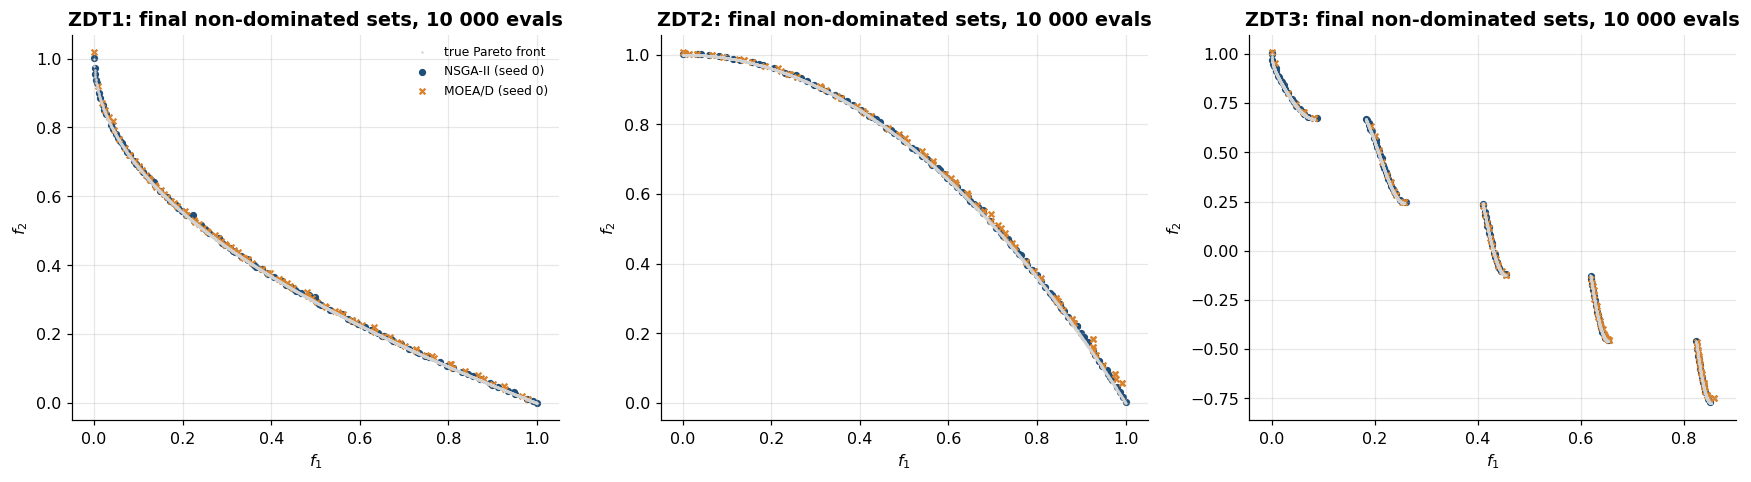

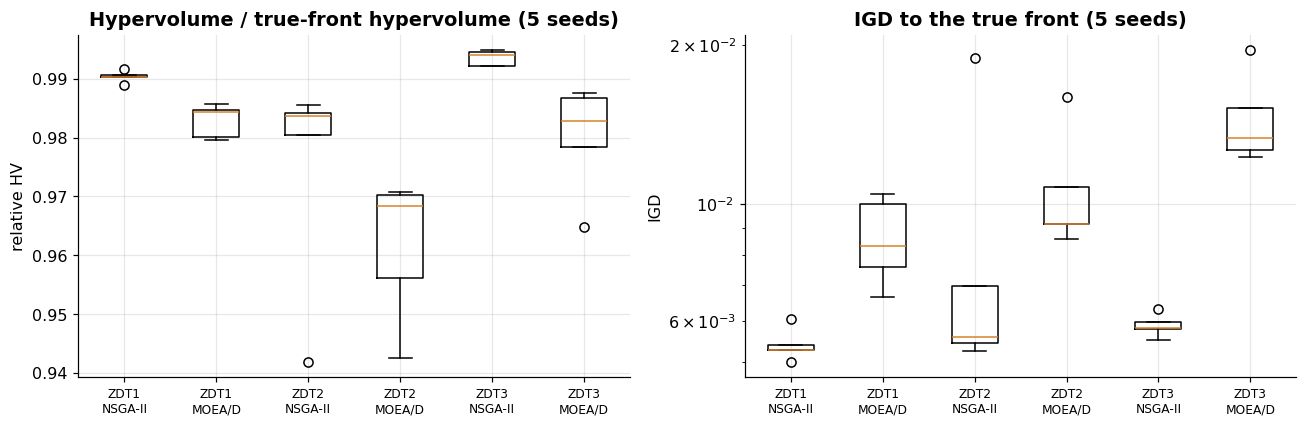

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, p in zip(axes, ["ZDT1", "ZDT2", "ZDT3"]):
    T_ = fronts[p]
    ax.plot(T_[:, 0], T_[:, 1], ".", ms=1.2, color="lightgrey", label="true Pareto front")
    for alg, col, mk in [("NSGA-II", PALETTE["blue"], "o"), ("MOEA/D", PALETTE["orange"], "x")]:
        A = finals_mo[p, alg]; ax.scatter(A[:, 0], A[:, 1], s=14, marker=mk, color=col, label=f"{alg} (seed 0)")
    ax.set(title=f"{p}: final non-dominated sets, 10 000 evals", xlabel="$f_1$", ylabel="$f_2$")
axes[0].legend(fontsize=8)
plt.tight_layout(); savefig("w6_zdt_fronts.png"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = [f"{p}\n{a}" for p in ["ZDT1", "ZDT2", "ZDT3"] for a in ["NSGA-II", "MOEA/D"]]
axes[0].boxplot([mo_res[p, a][0] / hv_true[p] for p in ["ZDT1", "ZDT2", "ZDT3"] for a in ["NSGA-II", "MOEA/D"]], tick_labels=labels)
axes[0].set(title="Hypervolume / true-front hypervolume (5 seeds)", ylabel="relative HV")
axes[1].boxplot([mo_res[p, a][1] for p in ["ZDT1", "ZDT2", "ZDT3"] for a in ["NSGA-II", "MOEA/D"]], tick_labels=labels)
axes[1].set(title="IGD to the true front (5 seeds)", ylabel="IGD", yscale="log")
for ax in axes: ax.tick_params(axis="x", labelsize=8)
plt.tight_layout(); savefig("w6_moea_indicators.png"); plt.show()

**Interpretation.** Both algorithms converge to the analytic fronts (IGD of order $10^{-2}$ or better). At this
budget NSGA-II has the higher median hypervolume and lower IGD on all three problems; with five seeds the
difference is significant on ZDT1 and ZDT3 but not on ZDT2 (see the printed $p$-values). Two mechanisms explain the
gap: the Tchebycheff decomposition fixes one search direction per subproblem, so MOEA/D's points follow the weight
vectors — uniform in *weight* space, not along a curved or disconnected front (visible on ZDT3, where several
subproblems share the endpoints of the disconnected pieces) — whereas NSGA-II's crowding distance adapts spacing to
the front actually found; and our MOEA/D keeps no external archive. The ranking is specific to two objectives and to
this variant: decomposition scales much better than dominance-based selection when $M$ grows (Zhang & Li 2007;
NSGA-III, Deb & Jain 2014, adopts reference directions for that reason).

**AI/ML connection.** Neural architecture search is intrinsically multi-objective — accuracy vs latency, FLOPs or
memory: NSGA-Net (Lu et al. 2019) uses NSGA-II, and hardware-aware NAS reports Pareto fronts rather than single
models. The same machinery serves accuracy–fairness trade-offs and multi-objective hyperparameter optimisation (e.g.
NSGA-II and MOTPE samplers in Optuna).

## Key takeaways
- Pareto dominance is a partial order; the output of a multi-objective metaheuristic is a *set* judged by convergence
  and spread, measured by hypervolume (Pareto-compliant) and IGD (needs a reference front).
- Fast non-dominated sorting computes all fronts in $O(MN^2)$ with counters and dominated sets; it agrees exactly with
  brute-force peeling, including ties and duplicates.
- Exact 2-D hypervolume is a sort plus a sweep; it matches closed forms ($0.21+2/3$, $0.21+1/3$) and Monte Carlo.
- NSGA-II = elitist GA + (rank, crowding) selection; MOEA/D = $N$ cooperating Tchebycheff subproblems — the latter
  reaches concave fronts that weighted sums cannot.

## Exercises
1. ★ Prove that Pareto dominance is irreflexive and transitive, and that the first front $\mathcal{F}_1$ of any finite
   set is non-empty.
2. ★★ Prove that every Pareto-optimal point minimises the Tchebycheff function for some weight vector (with
   $z^{\ast}$ strictly below the ideal point), and that the weighted sum cannot reach interior points of a strictly
   concave front.
3. ★★ Show that hypervolume is Pareto compliant: if $A$ weakly dominates $B$ then $\mathrm{HV}(A)\ge\mathrm{HV}(B)$. Show by
   a counterexample that IGD is not.
4. ★★ Implement the exact 3-D hypervolume by slicing along $f_3$ and validate it by Monte Carlo on DTLZ2 with 3 objectives.
5. ★★★ Implement NSGA-III's reference-point niching (Deb & Jain 2014) and compare it with NSGA-II and MOEA/D on DTLZ2
   with $M=3,5$ objectives in terms of IGD at equal budgets.
6. ★★★ Build a toy NAS problem: choose widths of a 3-layer MLP (a discrete vector) with objectives (validation error
   of a closed-form ridge-regression surrogate, parameter count). Run NSGA-II with integer mutation and plot the front.